# 二分类


本节为方便简洁的描述理论，先只讨论单样本输入，两个输入特征的情况，并将偏置b吸取到w中，单神经元的情况。

## 定义向量：

*   **输入向量**: $\mathbf{x} = [1, x_1, x_2]^T$
*   **权重向量**: $\mathbf{w} = [b, w_1, w_2]^T$

## 1. 感知器

### 前向传播：

1.  $z = {\mathbf{w}} \cdot {\mathbf{x}}$
    
2.  $\hat{y} = \text{sign}(z)$
    
3.  $L(\mathbf{w}) = y - \hat{y} $

### 反向传播：

#### 更新权重：

我们采用 $\{-1, +1\}$ 的输出，$(y - \hat{y})$ 的值只能是 -2, 0, 或 +2。

- 如果预测错误（即 $\hat{y} \neq y$），则按以下规则更新权重和偏置：
    $\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot (y - \hat{y}) \cdot \mathbf{x}$
    $\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot y \cdot \mathbf{x}$   (简化版本)
- 如果预测正确，则参数保持不变。

#### 数学直觉：

更新规则 $\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot y \cdot \mathbf{x}$ 非常巧妙。

*   如果真实标签 $y = +1$ 但被误分为 -1，我们需要增加 $\mathbf{w} \cdot \mathbf{x}$ 的值。将权重向输入向量 $\mathbf{x}$ 的方向增加（因为 $y=+1$），正好可以达到这个目的。
*   如果真实标签 $y = -1$ 但被误分为 +1，我们需要减少 $\mathbf{w} \cdot \mathbf{x}$ 的值。将权重向输入向量 $\mathbf{x}$ 的相反方向增加（因为 $y=-1$），正好可以达到这个目的。

> 真实值有反转方向的作用！！！

## 二、逻辑回归

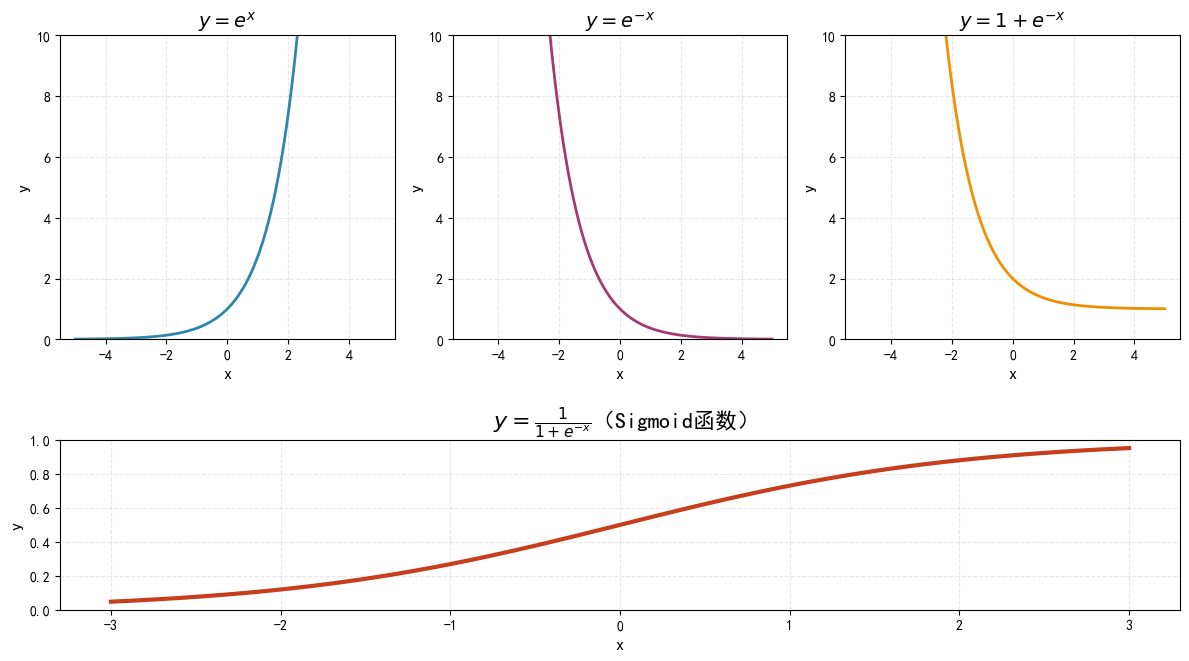

In [43]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt

# 配置Matplotlib参数，解决中文显示和负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# 1. 生成x轴数据，选择合适区间保证图像平滑
x = np.linspace(-5, 5, 1000)  # 前三个函数的x数据
x4 = np.linspace(-3, 3, 100)  # 单独为Sigmoid函数准备x数据（保持你的原有设置）

# 2. 计算四个函数的y值（对应Sigmoid演变过程）
y1 = np.exp(x)                # 第一个函数：y = e^x
y2 = np.exp(-x)               # 第二个函数：y = e^(-x)
y3 = 1 + np.exp(-x)           # 第三个函数：y = 1 + e^(-x)
y4 = 1 / (1 + np.exp(-x4))    # 第四个函数：Sigmoid函数 y = 1/(1+e^(-x))

# 3. 创建2行3列的网格布局，实现子图合并
# 画布大小调整为更适配2行3列布局（宽18，高8）
fig = plt.figure(figsize=(12, 8))

# 第一行：3个独立子图（各占1列，行索引0，列索引0、1、2）
ax1 = plt.subplot2grid((2, 3), (0, 0))  # 第1行第1列
ax2 = plt.subplot2grid((2, 3), (0, 1))  # 第1行第2列
ax3 = plt.subplot2grid((2, 3), (0, 2))  # 第1行第3列

# 第二行：合并3列，只放Sigmoid函数（行索引1，列索引0开始，跨3列）
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=3)

# 4. 绘制第一行的三个子图（保留你的原有样式设置）
# 子图1：y = e^x
ax1.plot(x, y1, color='#2E86AB', linewidth=2)
ax1.set_title(r'$y=e^x$', fontsize=14)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylim(0, 10)
ax1.set_aspect("equal")

# 子图2：y = e^(-x)
ax2.plot(x, y2, color='#A23B72', linewidth=2)
ax2.set_title(r'$y=e^{-x}$', fontsize=14)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_ylim(0, 10)
ax2.set_aspect("equal")

# 子图3：y = 1 + e^(-x)
ax3.plot(x, y3, color='#F18F01', linewidth=2)
ax3.set_title(r'$y=1+e^{-x}$', fontsize=14)
ax3.set_xlabel('x', fontsize=12)
ax3.set_ylabel('y', fontsize=12)
ax3.grid(alpha=0.3, linestyle='--')
ax3.set_ylim(0, 10)
ax3.set_aspect("equal")

# 5. 绘制第二行合并后的Sigmoid函数（放大显示，更清晰）
ax4.plot(x4, y4, color='#C73E1D', linewidth=3)  # 适当加粗线条，突出Sigmoid
ax4.set_title(r'$y=\frac{1}{1+e^{-x}}$（Sigmoid函数）', fontsize=16)  # 放大标题字体
ax4.set_xlabel('x', fontsize=12)
ax4.set_ylabel('y', fontsize=12)
ax4.grid(alpha=0.3, linestyle='--')
ax4.set_ylim(0, 1)  # Sigmoid函数取值范围为[0,1]
ax4.set_aspect("equal")

# 6. 调整子图间距，避免标签重叠
plt.tight_layout()
# 可选：微调上下行间距，让布局更美观（数值可按需调整）
plt.subplots_adjust(hspace=-0.2)

# 7. 显示图像
plt.show()

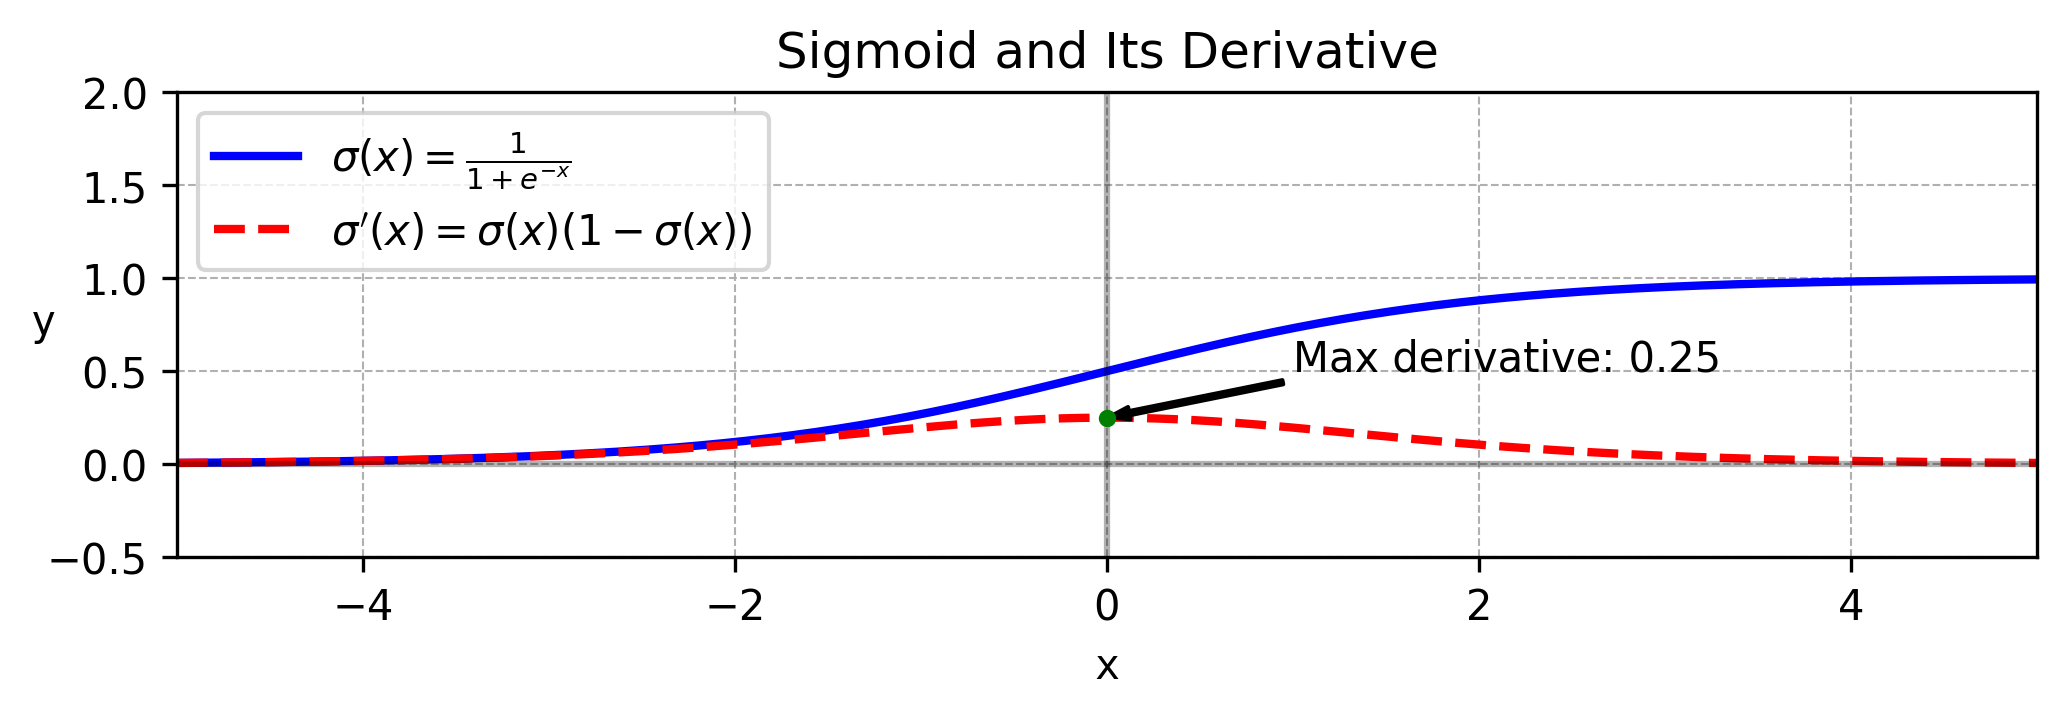

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义sigmoid函数及其导函数 (与之前相同)
def sigmoid(x):
    """sigmoid函数"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """sigmoid函数的导函数"""
    s = sigmoid(x)
    return s * (1 - s)

# 2. 生成数据
# 为了更好地展示aspect='equal'的效果，我们将x的范围缩小，使其与y的范围[-0.1, 1.1]更匹配
x = np.linspace(-5, 5, 400)
y_sigmoid = sigmoid(x)
y_derivative = sigmoid_derivative(x)

# 3. 创建图形和坐标轴对象 (OO方式的核心)
# fig是整个图表对象，ax是坐标轴对象
fig = plt.figure(figsize=(8, 8),dpi=300)
# 3. 创建图形和坐标轴对象
ax = fig.add_subplot()

# 4. 在坐标轴对象上进行绘制
ax.plot(x, y_sigmoid, label=r'$\sigma(x) = \frac{1}{1 + e^{-x}}$', color='blue', linewidth=2)
ax.plot(x, y_derivative, label=r"$\sigma'(x) = \sigma(x)(1 - \sigma(x))$", color='red', linestyle='--', linewidth=2)

# 5. 使用ax对象设置图表属性 (精细控制)
ax.set_title("Sigmoid and Its Derivative")
ax.set_xlabel(r"$\mathtt{x}$")
ax.set_ylabel(r"$\mathtt{y}$",  rotation=0,  # 文字旋转90度（垂直向下）
    verticalalignment='center',  # 垂直方向对齐到坐标轴中心（避免偏移）
    horizontalalignment='left'   # 水平方向靠左（贴近y轴）
             )

# --- 这是您提到的关键部分 ---
# 设置坐标轴的实际比例为1:1
# 'equal' 意味着数据坐标中的1单位长度在x轴和y轴上看起来是一样长的
ax.set_aspect('equal', adjustable='box')

# 设置x轴和y轴的显示范围，使其更对称
ax.set_xlim([-5, 5])
ax.set_ylim([-0.5, 2])

ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax.legend(loc="upper left")

# 标注导数的最大值点 (0, 0.25)
max_deriv_point = (0, 0.25)
ax.scatter(max_deriv_point[0], max_deriv_point[1], color='green', s=10, zorder=5)
ax.annotate(f'Max derivative: {max_deriv_point[1]}',
            xy=max_deriv_point,
            xytext=(1, 0.5),
            arrowprops=dict(facecolor='black', shrink=0.01, width=1,headwidth=3, headlength=5 ))

# 6. 显示图像
plt.show()

*   **真实标签**: $y \in \{0, 1\}$ (逻辑回归通常使用0/1标签)

### 前向传播：

1.  $z = \mathbf{w} \cdot \mathbf{x}$ 
2.  $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$ 
3.  $L(\mathbf{w}) = -[y \cdot \log\hat{y} + (1-y) \cdot \log(1-\hat{y})]$ 

### 反向传播：

#### 计算梯度：

1.  $\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$ 
2.  $\frac{\partial \hat{y}}{\partial z} = \hat{y} \cdot (1 - \hat{y})$ 
3.  $\frac{\partial z}{\partial \mathbf{w}} = \mathbf{x}$ 

#### 组合梯度（链式法则）：

$\frac{\partial L}{\partial \mathbf{w}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} = [\hat{y} - y] \cdot \mathbf{x}$

#### 更新权重（梯度下降）：

$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{\partial L}{\partial \mathbf{w}} = \mathbf{w} - \eta \cdot (\hat{y} - y) \cdot \mathbf{x}$

#### 数学直觉：

更新规则 $\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot (a - y) \cdot \mathbf{x}$ 体现了梯度下降的思想：
- 当预测概率 $a$ 大于真实标签 $y$ 时，$(a - y) > 0$，权重会减小
- 当预测概率 $a$ 小于真实标签 $y$ 时，$(a - y) < 0$，权重会增加
- 输入向量 $\mathbf{x}$ 决定了每个权重更新的方向和幅度

### 均方误差损失  

$L_{MSE} = \frac{1}{2}(y - \hat{y})^2$

其梯度为（需要链式法则）：

1.  $\frac{\partial L_{MSE}}{\partial \hat{y}} = - (y - \hat{y})$
2.  $\frac{\partial \hat{y}}{\partial z} = \hat{y}(1-\hat{y})$ （Sigmoid函数的导数）
3.  $\frac{\partial L_{MSE}}{\partial \mathbf{w}} = \frac{\partial L_{MSE}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} = - (y - \hat{y}) \cdot \hat{y}(1-\hat{y}) \cdot \mathbf{x}$

---

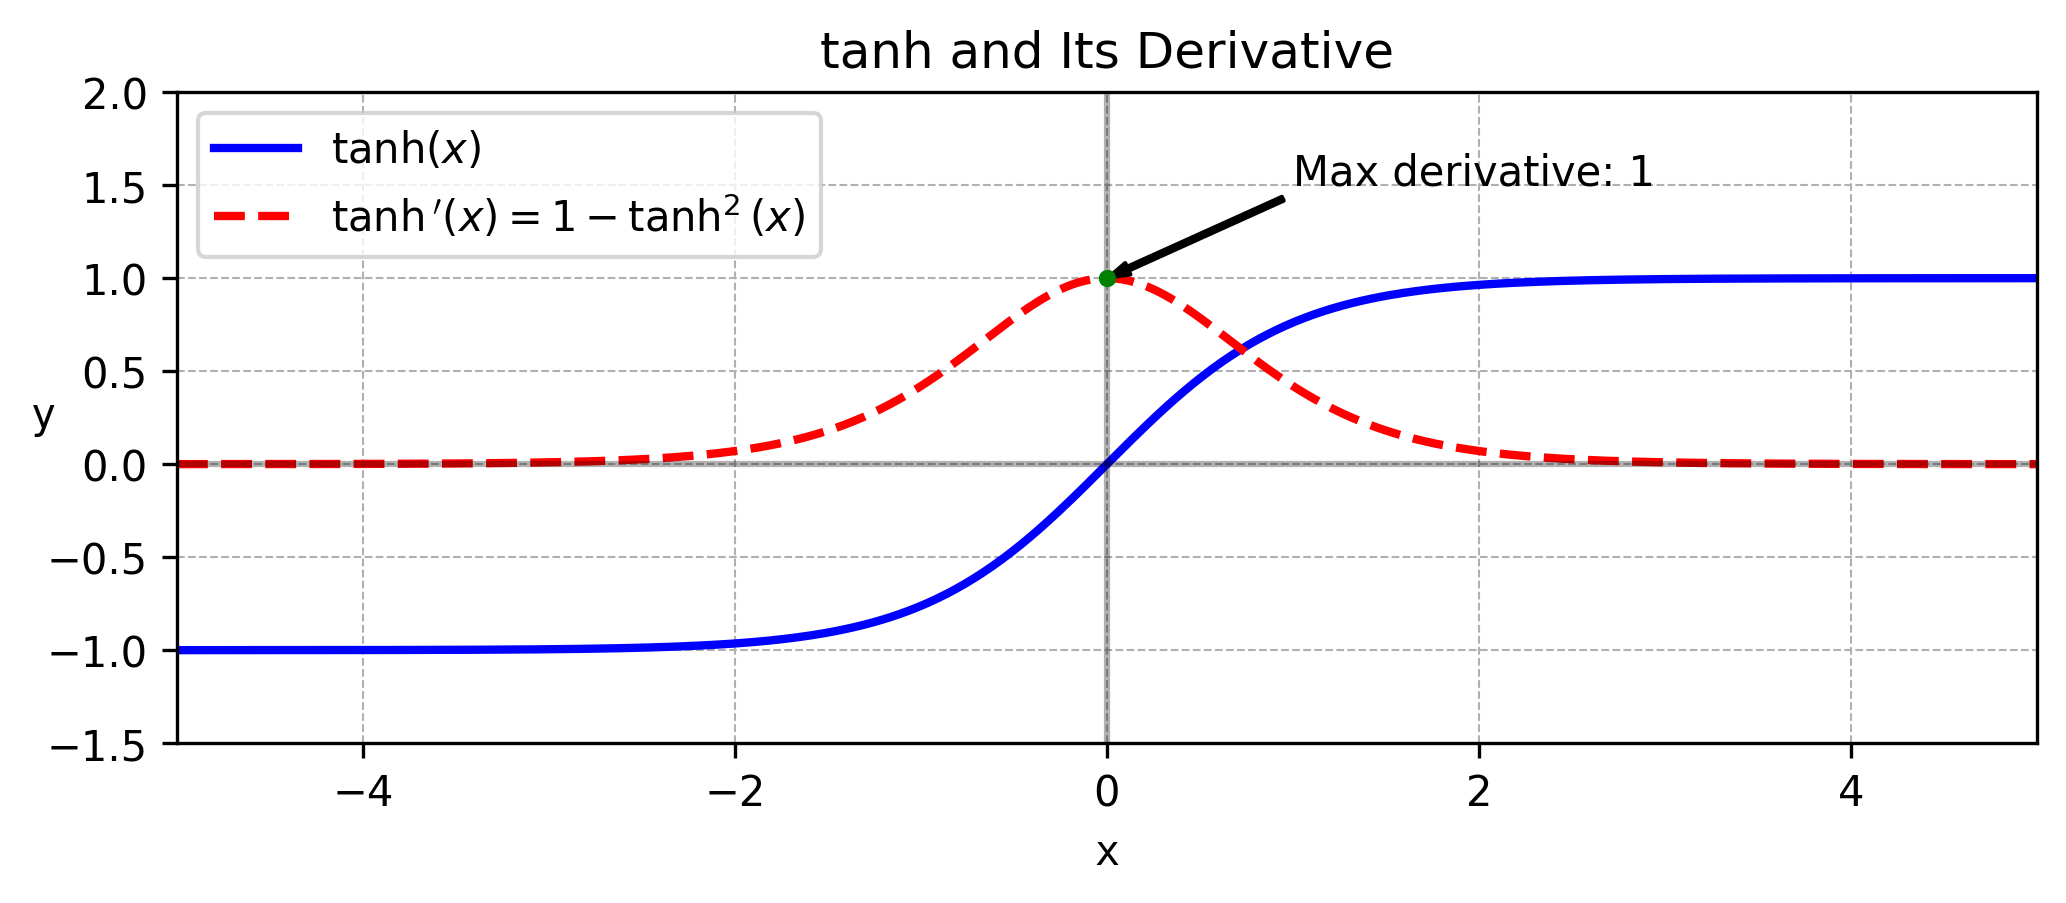

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义tanh函数及其导函数 (这是您需要的核心修改)
def tanh(x):
    """tanh函数"""
    return np.tanh(x)

def tanh_derivative(x):
    """tanh函数的导函数"""
    t = tanh(x)
    return 1 - t ** 2

# 2. 生成数据
# tanh的值域是(-1, 1)，其导数的值域是(0, 1]
x = np.linspace(-5, 5, 400)
y_tanh = tanh(x)
y_derivative = tanh_derivative(x)

fig = plt.figure(figsize=(8, 8),dpi=300)
# 3. 创建图形和坐标轴对象
ax = fig.add_subplot()

# 4. 在坐标轴对象上进行绘制
ax.plot(x, y_tanh, label=r'$\tanh(x)$', color='blue', linewidth=2)
ax.plot(x, y_derivative, label=r"$\tanh'(x) = 1 - \tanh^2(x)$", color='red', linestyle='--', linewidth=2)

# 5. 使用ax对象设置图表属性
ax.set_title("tanh and Its Derivative")
ax.set_xlabel(r"$\mathtt{x}$")
ax.set_ylabel(r"$\mathtt{y}$",  rotation=0,  # 文字旋转90度（垂直向下）
    verticalalignment='center',  # 垂直方向对齐到坐标轴中心（避免偏移）
    horizontalalignment='left'   # 水平方向靠左（贴近y轴）
             )

# 设置坐标轴的实际比例为1:1
ax.set_aspect('equal', adjustable='box')

# 设置x轴和y轴的显示范围，以更好地展示tanh的特性
ax.set_xlim([-5, 5])
ax.set_ylim([-1.5, 2]) # tanh的值域是(-1, 1)，导数是(0, 1]

ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax.legend(loc="upper left")

# 标注导数的最大值点 (0, 1)
max_deriv_point = (0, 1)
ax.scatter(max_deriv_point[0], max_deriv_point[1], color='green', s=10, zorder=5)
ax.annotate(f'Max derivative: {max_deriv_point[1]}',
            xy=max_deriv_point,
            xytext=(1, 1.5),
            arrowprops=dict(facecolor='black', shrink=0.01, width=1,headwidth=3, headlength=5 ))

# 6. 显示图像
plt.show()

## 3. 基于Tanh的分类模型

*   **真实标签**: $y \in \{-1, +1\}$ (为了与Tanh的输出范围匹配)

### 前向传播：

1.  $z = \mathbf{w} \cdot \mathbf{x}$ 
2.  $\hat{y} = \tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$ (输出范围 $[-1, +1]$，可看作一个“软”的类别分数)
3.  $L(\mathbf{w}) = \frac{1}{2}(y - \hat{y})^2$ (采用均方误差损失)

### 反向传播：

#### 计算梯度：

1.  $\frac{\partial L}{\partial \hat{y}} = - (y - \hat{y})$
2.  $\frac{\partial \hat{y}}{\partial z} = 1 - \hat{y}^2$ (这是Tanh函数的导数)
3.  $\frac{\partial z}{\partial \mathbf{w}} = \mathbf{x}$

#### 组合梯度（链式法则）：

$\frac{\partial L}{\partial \mathbf{w}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} = - (y - \hat{y}) \cdot (1 - \hat{y}^2) \cdot \mathbf{x}$

#### 更新权重（梯度下降）：

$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{\partial L}{\partial \mathbf{w}} = \mathbf{w} + \eta \cdot (y - \hat{y}) \cdot (1 - \hat{y}^2) \cdot \mathbf{x}$

#### 数学直觉：

更新规则 $\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot (y - \hat{y}) \cdot (1 - \hat{y}^2) \cdot \mathbf{x}$ 结合了误差信号和激活函数的置信度：
-   $(y - \hat{y})$：**误差项**。当预测 $\hat{y}$ 与真实 $y$ 相差越大，更新幅度越大。
-   $(1 - \hat{y}^2)$：**置信度项**。这是Tanh导数的核心特性。当 $|\hat{y}| \approx 1$ 时（即模型对自己当前的“硬”预测非常确信），该项接近于0，梯度消失，更新量变小。当 $\hat{y} \approx 0$ 时（即模型处于“不确定”状态），该项最大，更新量最大。这起到了自动调节学习步长的作用。
-   $\mathbf{x}$：**输入项**。决定了每个权重参数更新的方向和相对大小。


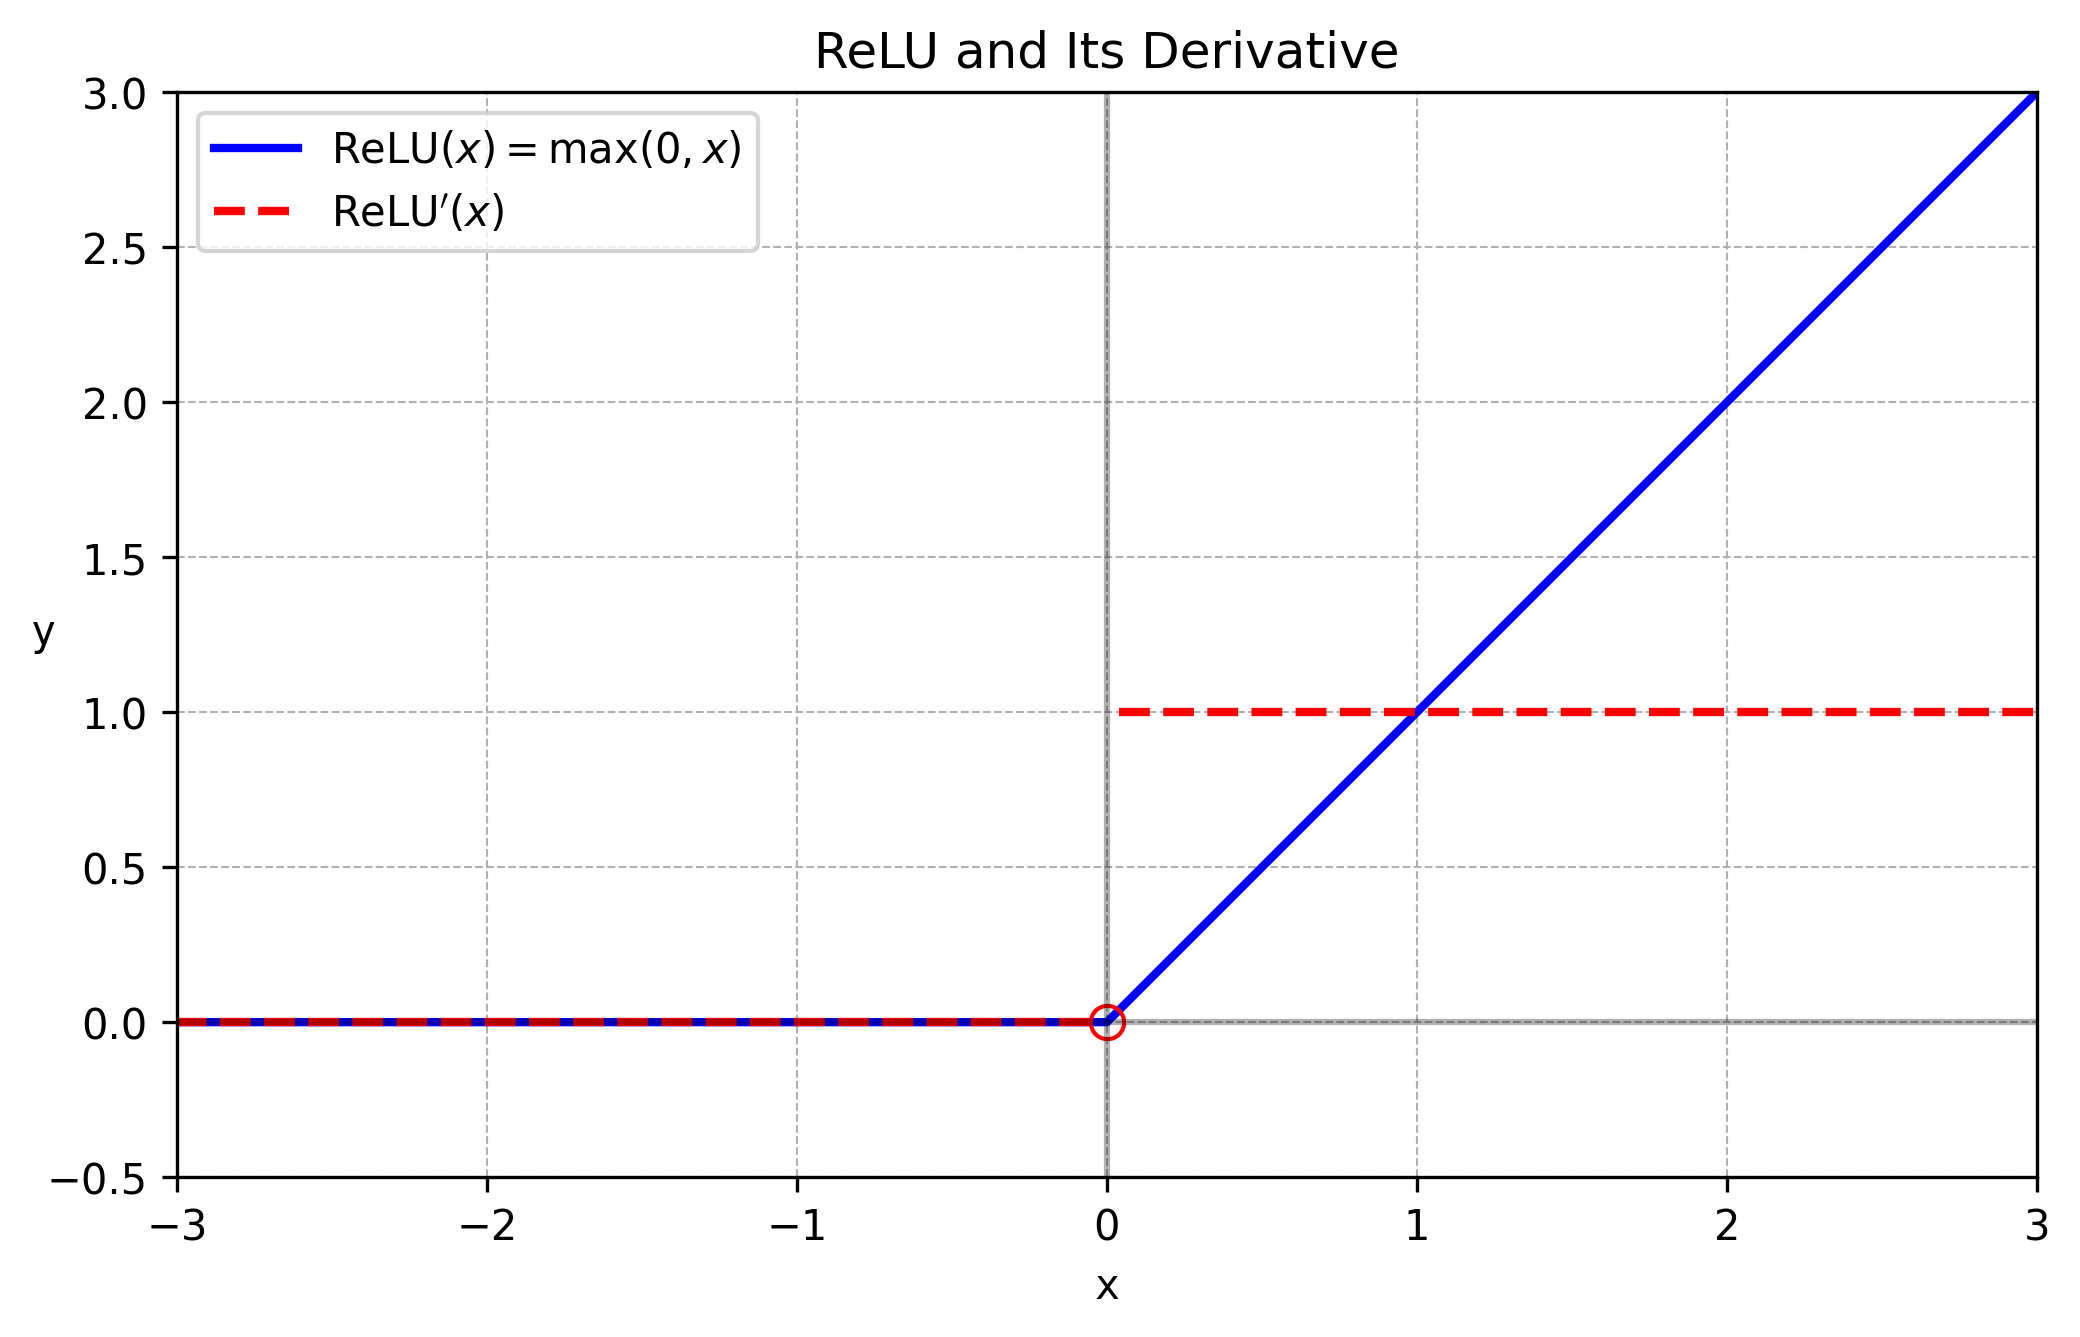

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义ReLU函数及其导函数
def relu(x):
    """ReLU函数"""
    return np.maximum(0, x)

def relu_derivative(x):
    """ReLU函数的导函数"""
    # 当x > 0时，导数为1
    # 当x < 0时，导数为0
    # 当x = 0时，导数不存在，但在实践中通常定义为0或1
    return np.where(x > 0, 1, 0)

# 2. 生成数据
# ReLU在x>0时线性增长，我们将x范围扩大以展示这一点
x = np.linspace(-5, 10, 400)
y_relu = relu(x)
y_derivative = relu_derivative(x)

# --- 为了精确绘制x=0处的跳跃，我们将数据点分开处理 ---
# 这是一个更精细的绘图技巧，可以避免在x=0处出现不必要的连线
x_pos = x[x > 0]
y_deriv_pos = y_derivative[x > 0]
x_neg = x[x < 0]
y_deriv_neg = y_derivative[x < 0]

fig = plt.figure(figsize=(8, 8), dpi=300)
# 3. 创建图形和坐标轴对象
ax = fig.add_subplot()

# 4. 在坐标轴对象上进行绘制
ax.plot(x, y_relu, label=r'$\mathrm{ReLU}(x) = \max(0, x)$', color='blue', linewidth=2)

# 使用分段的方式绘制导数，以正确显示x=0处的不连续点
ax.plot(x_neg, y_deriv_neg, color='red', linestyle='--', linewidth=2)
ax.plot(x_pos, y_deriv_pos, color='red', linestyle='--', linewidth=2, label=r"$\mathrm{ReLU}'(x)$")

# 在x=0处标记一个空心圆，表示该点不连续（导数不存在）
ax.plot(0, 0, color='red', marker='o', markerfacecolor='none', markersize=8, linestyle='')

# 5. 使用ax对象设置图表属性
ax.set_title("ReLU and Its Derivative")
ax.set_xlabel(r"$\mathtt{x}$")
ax.set_ylabel(r"$\mathtt{y}$",  rotation=0,
    verticalalignment='center',
    horizontalalignment='left'
             )

# 设置坐标轴的实际比例为1:1
ax.set_aspect('equal', adjustable='box')

# 设置x轴和y轴的显示范围，以更好地展示ReLU的特性
ax.set_xlim([-3, 3])
ax.set_ylim([-0.5, 3]) # ReLU在x>0时会线性增长

ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax.legend(loc="upper left")

# 标注导数在x>0区域的值为1
# ax.annotate(r'$\mathrm{ReLU}(x) = 1$ for $x > 0$',
#             xy=(2, 1),
#             xytext=(1.5, 1.5),
#             arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=3, headlength=5))

# # 标注导数在x<0区域的值为0
# ax.annotate(r'$\mathrm{ReLU}(x) = 0$ for $x < 0$',
#             xy=(-1, 0),
#             xytext=(-2, 1),
#             arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=3, headlength=5))


# 6. 显示图像
plt.show()

## 4. 基于 ReLU 的分类模型

*   **真实标签**: $y \in {0, 1}$ (为了与 ReLU 的非负输出相匹配)

### 前向传播：

1.  $z = \mathbf{w} \cdot \mathbf{x}$
2.  $\hat{y} = \max(0, z)$ 
3.  $L(\mathbf{w}) = \frac{1}{2}(y - \hat{y})^2$

> $\hat{y}$(输出范围 $[0, +\infty)$，表示一种“置信度分数”)

### 反向传播：

#### 计算梯度：

1.  $\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$ 
2.  $\frac{\partial \hat{y}}{\partial z} = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$ 
3.  $\frac{\partial z}{\partial \mathbf{w}} = \mathbf{x}$ 

#### 组合梯度（链式法则）：

$\frac{\partial L}{\partial \mathbf{w}} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}} = (\hat{y} - y) \cdot \left( \frac{\partial \hat{y}}{\partial z} \right) \cdot \mathbf{x}$

将 ReLU 的导数代入，得到分段函数：

$\frac{\partial L}{\partial \mathbf{w}} = \begin{cases} (\hat{y} - y) \cdot \mathbf{x} & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$

#### 更新权重（梯度下降）：

$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{\partial L}{\partial \mathbf{w}}$

即：
$\mathbf{w} \leftarrow \begin{cases} \mathbf{w} - \eta \cdot (\hat{y} - y) \cdot \mathbf{x} & \text{if } z > 0 \\ \mathbf{w} & \text{if } z \leq 0 \end{cases}$ 

---

In [2]:
import torch
import numpy as np

In [3]:
# 已知点
X = torch.tensor([(-1.0, 1.0),(1.0,-1.0)])
Y = torch.tensor([[1],[-1]])
X

tensor([[-1.,  1.],
        [ 1., -1.]])

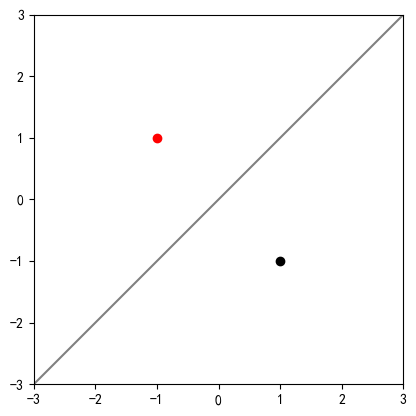

In [13]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X[0,0], X[0,1], color="r")
ax.scatter(X[1,0], X[1,1], color="k")

ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
ax.set_aspect("equal")
ax.plot(np.linspace(-3,3,20), np.linspace(-3,3,20),"gray" )
plt.show()

$$
Ax+By+C = 0
$$

In [14]:
w = torch.tensor([[1.0],[-1.0]], requires_grad=True )
w

tensor([[ 1.],
        [-1.]], requires_grad=True)

In [6]:
b = torch.tensor(0.0, requires_grad=True)

In [7]:
z = X @ w +b

In [9]:
loss = z - Y
loss

tensor([[-3.],
        [ 3.]], grad_fn=<SubBackward0>)

## 从逻辑回归的一个线性函数，到两个线性函数